In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Core/Machine Learning/Data/12-health_risk_classification.csv")
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [4]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


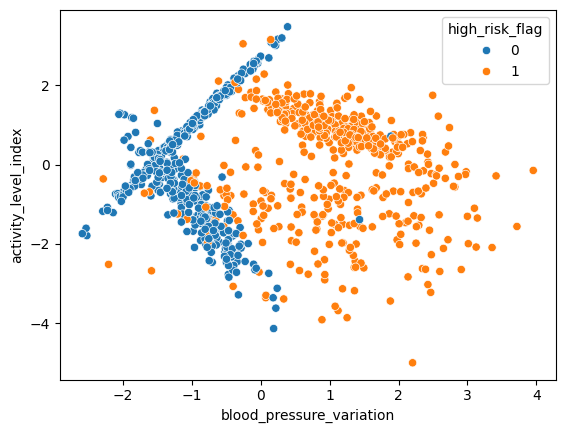

In [5]:
sns.scatterplot(x='blood_pressure_variation', y='activity_level_index', hue='high_risk_flag', data=df)
plt.show()

In [6]:
df['high_risk_flag'].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [7]:
X = df.drop(['high_risk_flag'], axis=1)
y = df['high_risk_flag']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

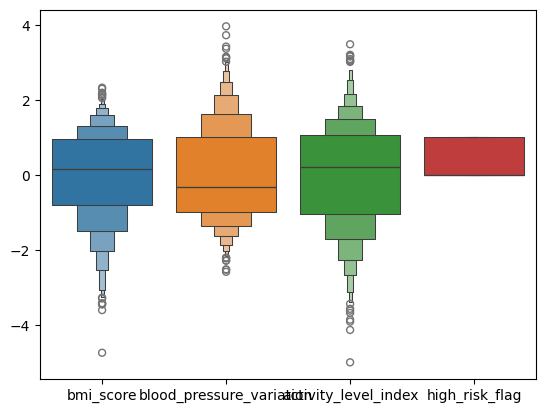

In [9]:
sns.boxenplot(df)
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm='auto', weights='uniform', metric='minkowski', n_jobs=-1)

In [14]:
classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_jobs=-1)

In [15]:
y_pred = classifier.predict(X_test_scaled)

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[130   2]
 [ 10 108]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96       132
           1       0.98      0.92      0.95       118

    accuracy                           0.95       250
   macro avg       0.96      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

Accuracy Score: 0.952


In [18]:
# KNN for Regression

In [19]:
df_reg = pd.read_csv("/Core/Machine Learning/Data/12-house_energy_regression.csv")
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [20]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [21]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


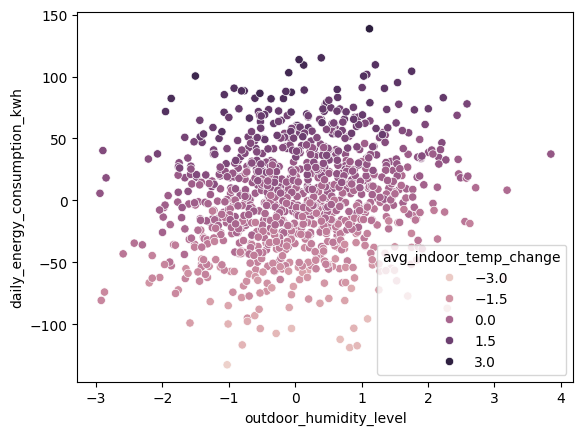

In [22]:
sns.scatterplot(x='outdoor_humidity_level', y='daily_energy_consumption_kwh', hue='avg_indoor_temp_change', data=df_reg)
plt.show()

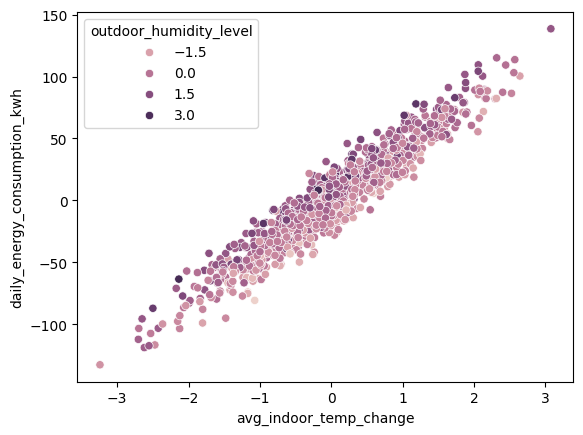

In [23]:
sns.scatterplot(x='avg_indoor_temp_change', y='daily_energy_consumption_kwh', hue='outdoor_humidity_level', data=df_reg)
plt.show()

In [24]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [26]:
X = df_reg.drop(['daily_energy_consumption_kwh'], axis=1)
y = df_reg['daily_energy_consumption_kwh']

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.neighbors import KNeighborsRegressor

In [30]:
regressor = KNeighborsRegressor(n_neighbors=5, algorithm='auto', weights='uniform', metric='minkowski', n_jobs=-1)

In [31]:
regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_jobs=-1)

In [32]:
y_pred = regressor.predict(X_test_scaled)

In [36]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [37]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 9.196930595794969
Mean Squared Error: 134.49407673040622
R^2 Score: 0.9130816088550286


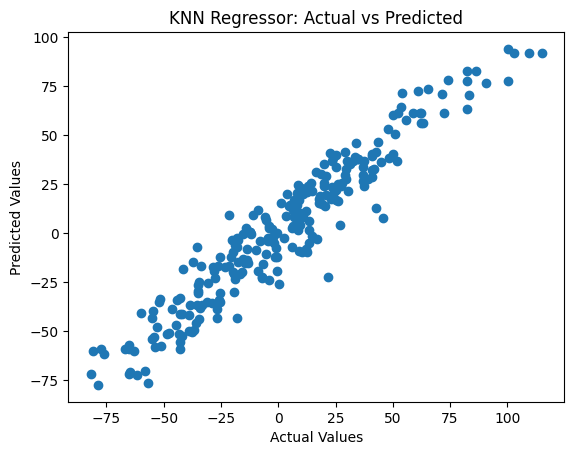

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN Regressor: Actual vs Predicted")
plt.show()